Successfully loaded config file: C:\Users\sens\Desktop\FingernailProjection\FingernailProjection\config.json
Changed attributes: ocr_credits, fingernail_projection_color, projected_text_font_size, projection_target, projection_rotation, fingernail_center_shift_factor, skincolor_open_radius, skincolor_close_radius, linestring_resample_distance, linestring_smoothing, position_queue_length, max_cursor_mean_deviation_for_snapshot, distance_from_cursor_for_snapshot_reset, projection_delay_ms, cursor_circle_start_radius_mm, cursor_size, cursor_color, cursor_circle_thickness, standstill_color, cutout_size_as_multiple_of_tip_to_joint, cutout_size_mm, text_scale, text_threshold_mode, text_threshold_manual_value, sharpening_strength, fingermark_down_move_mm, finger_cursor_move_up_mm, finger_cursor_position_smoothing, finger_angle_smoothing, exposure_time, image_rotation, mediapipe_use_complex_model, min_mediapipe_confidence, mediaipipe_image_smallering_factor, debug_screen_index, projection_scre

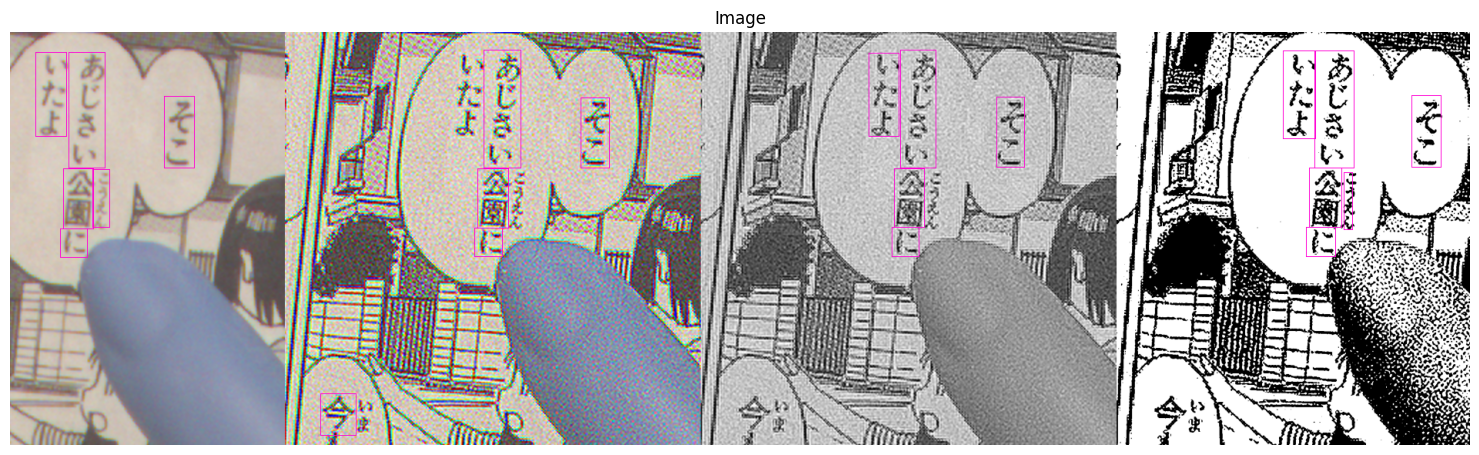

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from config import Config
from text_detection import TextDetection
from automatic_config_reloader import AutomaticConfigReloader
from enums import *
from drawing import *
import plotting
from google_ocr_data import GoogleOcrData
from helper import *

config_loader = AutomaticConfigReloader(
    r"C:\Users\sens\Desktop\FingernailProjection\FingernailProjection\config.json", Config
)
config: Config = config_loader.config

path = r"C:\Users\sens\Desktop\FingernailProjection\Doku\OCR-preprocessing.png"
# path = r"C:\Users\sens\Desktop\FingernailProjection\FingernailProjection\test.jpg"
# path = r"C:\Users\sens\Desktop\FingernailProjection\FingernailProjection\prototyping\Yotsubato-Manga-Recording.png"

image = cv2.imread(path)

# data: GoogleOcrData = picke_load_or_create(
#     r"C:\Users\sens\Desktop\FingernailProjection\FingernailProjection\prototyping\OCR-Test.pkl",
#     lambda: GoogleOcrData.from_image(image, config),
# )
data = GoogleOcrData.from_image(image, config)

boundingbox_drawcalls = TextDetection.get_bounding_box_drawcalls(data.word_detections, None, config)
for drawcall in boundingbox_drawcalls:
    drawcall(image)
plotting.plot_rgb_image(image)